<table class="tfo-notebook-buttons" align="left">
<td style="border: none;">
<a target="blank" href="https://colab.research.google.com/github/Hari31416/Portfolio/blob/main/Titanic/Models%20I.ipynb?hl=en"><img src="https://colab.research.google.com/img/colab_favicon_256px.png" width="28" height="28"/>Run on Google Colab</a></td>
<td style="border: none;">
<a target="blank" href="https://github.com/Hari31416/Portfolio/blob/main/Titanic/Models%20I.ipynb"><img src="https://cdn.icon-icons.com/icons2/2368/PNG/512/github_logo_icon_143772.png" width="28" height="28"/>View on Github</a></td>
<td style="border: none;">
</table>

# Preparation

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## loading the data

In [2]:
train = pd.read_csv('train_final.csv')
test = pd.read_csv('test_final.csv')

In [3]:
train.head()

,Survived,Pclass,Sex,SibSp,Parch,FamilySize,Embarked_Q,Embarked_S,Title_Master,Title_Miss,...,Ticket_first_letter_7,Ticket_first_letter_X,Cabin_First_B,Cabin_First_C,Cabin_First_D,Cabin_First_E,Cabin_First_F,Cabin_First_N,Age,Fare
0,0,3,0,1,0,2,0,1,0,0,...,0,1,0,0,0,0,0,1,-0.565587,-0.502445
1,1,1,1,1,0,2,0,0,0,0,...,0,1,0,1,0,0,0,0,0.624229,0.786845
2,1,3,1,0,0,1,0,1,0,1,...,0,1,0,0,0,0,0,1,-0.268133,-0.488854
3,1,1,1,1,0,2,0,1,0,0,...,0,0,0,1,0,0,0,0,0.401138,0.420730
4,0,3,0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,1,0.401138,-0.486337


In [4]:
test.head()

,Pclass,Sex,SibSp,Parch,FamilySize,Embarked_Q,Embarked_S,Title_Master,Title_Miss,Title_Mr,...,Ticket_first_letter_7,Ticket_first_letter_X,Cabin_First_B,Cabin_First_C,Cabin_First_D,Cabin_First_E,Cabin_First_F,Cabin_First_N,Age,Fare
0,3,0,0,0,1,1,0,0,0,1,...,0,0,0,0,0,0,0,1,0.337221,-0.497350
1,3,1,1,0,2,0,1,0,0,0,...,0,0,0,0,0,0,0,1,1.302134,-0.512214
2,2,0,0,0,1,1,0,0,0,1,...,0,0,0,0,0,0,0,1,2.460031,-0.464037
3,3,0,0,0,1,0,1,0,0,1,...,0,0,0,0,0,0,0,1,-0.241727,-0.482412
4,3,1,1,1,3,0,1,0,0,0,...,0,0,0,0,0,0,0,1,-0.627692,-0.417429


In [5]:
columns = test.columns
columns

Index(['Pclass', 'Sex', 'SibSp', 'Parch', 'FamilySize', 'Embarked_Q',
       'Embarked_S', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs',
       'Title_Other', 'Title_Rev', 'Ticket_first_letter_2',
       'Ticket_first_letter_3', 'Ticket_first_letter_4',
       'Ticket_first_letter_6', 'Ticket_first_letter_7',
       'Ticket_first_letter_X', 'Cabin_First_B', 'Cabin_First_C',
       'Cabin_First_D', 'Cabin_First_E', 'Cabin_First_F', 'Cabin_First_N',
       'Age', 'Fare'],
      dtype='object')

In [6]:
X = train.drop(['Survived'], axis=1).values
y = train['Survived'].values

### Creating the train and test data

In [7]:
len(X)

891

Since there are just 891 rows in the train data, we will use a test size of 0.25 to create the test data.

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [9]:
len(X_train),len(X_test)

(668, 223)

## Modeling

### Procedure

Since we have already standardized the data, we'll jump directly to the model creation. We'll start from the simplest, `LinearRegression` and keep on increasing the complexity until we get a good model. The process will be as follows:
1. Create a model using default parameters
2. Fit the model to the training data and get model performance
3. Create a `GridSearchCV` object to find the best parameters for the model
4. Fit the model to the training data and get model performance
5. Repeat steps 1-4 for different models

Since this is a classification problem, the models we'll use are:
1. `LogisticRegression`
2. `KNeighborsClassifier`
3. `SVC`
4. `DecisionTreeClassifier`
5. `RandomForestClassifier`
6. `GaussianNB`
7. `GradientBoostingClassifier`
8. `XGBClassifier`
9. `BaggingClassifier`
10. `AdaBoostClassifier`
11. `ExtraTreesClassifier`

...and more( if I can find them!).

With every model, I'll briefly describe the parameters that we'll be using. If we created all these models in a single notebook, it will be huge. So I'll create a number of notebooks.

To keeptrack of various models and their performance, I'll create a dictionary with model name as key and a dictionary of performance metrics as values.

### Performance Metrics

In previous notebook, we saw that this classification is not perfectly balanced as only about 39% passengers survived. So `accuracy` is not that good a metric. However, we'll be using accuracy along with `precision`, `recall`, `f1_score` and  `roc_auc_score` to evaluate the model performance. These are the parameters, we'll be saving in the dictionary. We'll also plot the confusion matrix and ROC curve. So, the metrics we'll be saving in the dictionary are:
1. `accuracy`
2. `precision`
3. `recall`
4. `f1_score`
5. `roc_auc_score`

Let's create some helper functions.

### Helper Functions

I'll be using the `shelve` module to save the dictionary. The dictionary is loaded in the code cell below and given the name `models_performance`. 

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report
from life_saving_tools import Notification
from sklearn.model_selection import GridSearchCV
import shelve
n = Notification.Notification()
params = {}

def load_performance_dict(file = 'models_performance'):
    """
    This function loads the performance of a model from the `model_performance` \\
        dictionary.

    Parameters
    ----------
    model_name : string
        the name of the model to load from the `model_performance` dictionary

    Returns
    -------
    model_performance : dictionary
    """
    shelve_file = shelve.open(file)

    try:
        dictionary = shelve_file[file]
    except:
        dictionary = {}

    shelve_file.close()
    return dictionary

models_performance = load_performance_dict('models_performance')
models_on_train = load_performance_dict('models_on_train')

def save_performance_dict(file = 'models_performance', dictionary = models_performance):
    """
    This function saves the model_performance dictionary to a shelve file.

    Parameters
    ----------
    file : string
        the name of the shelve file to save the dictionary to

    Returns
    -------
    None
    """
    shelve_file = shelve.open(file)
    shelve_file[file] = dictionary
    shelve_file.close()

def perform_grid_search(model, params = params, X= X_train, y=y_train, 
    text = False, play = True, cv = 5, scoring = 'roc_auc', **kwargs):
    """
    Performs grid serach on the model and returns the best model with parameters.

    Parameters
    ----------
    model : sklearn model

    X : training data
        defualt is X_train

    y : target data
        defualt is y_train

    params : dictionary
        the parameters to search over
        defualt is params

    text : boolean
        if True, a notification is sent to whatsapp
        defualt is False
    
    play : boolean
        if True, music is played
        defualt is True

    cv : number of folds for cross validation
        defualt is 5

    scoring : scoring metric
        defualt is 'roc_auc'

    verbose : verbosity level
        defualt is 1

    Returns
    -------
    grid_search : sklearn GridSearchCV object
    """
    grid = GridSearchCV(model, params, cv=cv, scoring=scoring, **kwargs)
    grid.fit(X, y)

    best_estimator = grid.best_estimator_
    best_params = grid.best_params_
    best_score = grid.best_score_
    message = f"""Following is the best model and its parameters:\n\
Best Model:\n{best_estimator}\nBest params:\
\n{best_params}\nBest score: {best_score}"""

    if text:
        n.send_whatsapp_text(message)
    
    if play:
        n.play_n_stop()
    print(message)
    return grid

def visualize_model(model, features = X_test, target = y_test):
    """
    This function plots the confusion metrics and classification report

    Parameters
    ----------
    model : sklearn model

    Returns
    -------
    None
    """
    #predicting on the data
    y_pred = model.predict(features)
    
    #Printing the classification report
    print(classification_report(target, y_pred))
    
    #Confusion matrix
    cm = confusion_matrix(target, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.show()

def evaluate_model(model, model_name = None, train = False, final = False, X = X_test, y = y_test):
    """
    The function takes a model as input and creats a dictionary with the model's \\
        accuracy, precision, recall, f1 score, and roc_auc_score and add them to the \\
        `model_performance` dictionary and returns it. The `model_performance` dictionary \\
        is instantiated just before this function is created.

    Parameters
    ----------
    model : sklearn model

    model_name : string
        the name of the model to store as a key in the `model_performance` dictionary

    final : boolean
        if True, the scores are added to the `model_performance` dictionary as well

    Returns
    -------
    model_performance : dictionary
    """
    #Making predictions on the test set
    y_pred = model.predict(X)

    #Getting the metrics
    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    roc_auc = roc_auc_score(y, y_pred)

    if final:
        if train:
            dictionary = models_on_train
            file = "models_on_train"
        else:
            dictionary = models_performance
            file = "models_performance"
    #Adding the metrics to the model_performance dictionary
        if model_name is None:
            model_name = type(model).__name__

        dictionary[model_name] = {
                'accuracy': accuracy, 'precision': precision, 
                'recall': recall, 'f1': f1, 'roc_auc': roc_auc}
        save_performance_dict(file=file, dictionary=dictionary)
        return dictionary[model_name]
    else:
        return {'accuracy': accuracy, 'precision': precision, 
                'recall': recall, 'f1': f1, 'roc_auc': roc_auc}

### Saving Model Parameters

We'll also save the parameters of best model in a dictionary. That way, we won't have to run the grid search again.

In [19]:
model_params = shelve.open('model_params')

# Simple Models

## Logistics Regression

### Default Parameters

In [15]:
from sklearn.linear_model import LogisticRegression

lr_base = LogisticRegression()
lr_base.fit(X_train, y_train)

LogisticRegression()

In [18]:
lr_base_params = lr_base.get_params()
model_params['lr_base'] = lr_base_params

In [12]:
evaluate_model(lr_base, 'lr_base', final = True)

{'accuracy': 0.8026905829596412,
 'precision': 0.7472527472527473,
 'recall': 0.7640449438202247,
 'f1': 0.7555555555555554,
 'roc_auc': 0.7962015763877244}

              precision    recall  f1-score   support

           0       0.84      0.83      0.83       134
           1       0.75      0.76      0.76        89

    accuracy                           0.80       223
   macro avg       0.79      0.80      0.80       223
weighted avg       0.80      0.80      0.80       223



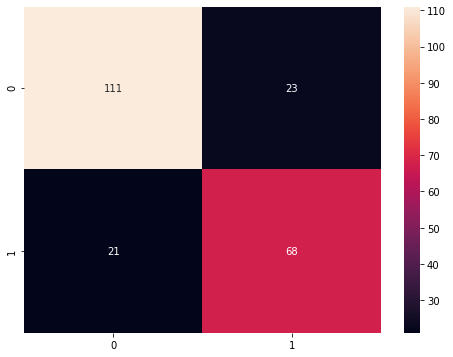

In [13]:
visualize_model(lr_base)

In [14]:
evaluate_model(lr_base, 'lr_base', train = True,
    final = True, X= X_train, y=y_train)

{'accuracy': 0.8532934131736527,
 'precision': 0.8297872340425532,
 'recall': 0.7707509881422925,
 'f1': 0.7991803278688524,
 'roc_auc': 0.837182722986809}

### Finding the best parameters

#### Parameters
* `C`: Inverse of regularization strength; must be a positive float. Like in SVM, smaller values specify stronger regularization.
* `fit_intercept`: bool, default True. Whether to calculate the intercept for this model. If set to false, no intercept will be used in calculations (e.g. data is expected to be already centered).
* `penalty`: {‘l1’, ‘l2’, ‘elasticnet’}, default ‘l2’. The penalty to be used.
* `solver`: {‘newton-cg’, ‘lbfgs’, ‘liblinear’, ‘sag’, ‘saga’}, default 'lbfgs'. Algorithm to use in the optimization problem.

#### Running GridSearchCV

I'll be using the training data during `GridSearchCV`. After that, I'll be using the best parameters to create the model, fit it and evaluate it on test data. The number of folds will be 3.

In [16]:
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')
params = {'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2', 'elasticnet'],
            'fit_intercept': [True, False], 'l1_ratio': [0, 0.1, 0.5, 0.9, 1]}

lr_base = LogisticRegression(solver='saga', random_state=42, max_iter=10000)
grid_1 = perform_grid_search(lr_base, params)

Following is the best model and its parameters:
Best Model:
LogisticRegression(C=1, l1_ratio=0.9, max_iter=10000, penalty='elasticnet',
                   random_state=42, solver='saga')
Best params:
{'C': 1, 'fit_intercept': True, 'l1_ratio': 0.9, 'penalty': 'elasticnet'}
Best score: 0.8684923222300969


In [ ]:
evaluate_model(grid_1.best_estimator_)

{'accuracy': 0.820627802690583,
 'precision': 0.7692307692307693,
 'recall': 0.7865168539325843,
 'f1': 0.7777777777777778,
 'roc_auc': 0.8149002180110683}

              precision    recall  f1-score   support

           0       0.86      0.84      0.85       134
           1       0.77      0.79      0.78        89

    accuracy                           0.82       223
   macro avg       0.81      0.81      0.81       223
weighted avg       0.82      0.82      0.82       223



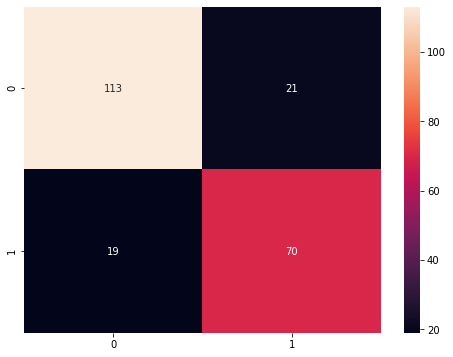

In [ ]:
visualize_model(grid_1.best_estimator_)

Let's narrow down the parameters search for grid search and see if we can beat the above parameters.

In [ ]:
params = {'C': [0.5, 0.7, 1, 1.2, 1.5], 'penalty': ['elasticnet'],
        "l1_ratio": [0.3, 0.6, 0.9, 1.2, 1.5]}

grid_2 = perform_grid_search(lr_base, params)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done 125 out of 125 | elapsed:   19.2s finished


SM8258fff2900e48c8bd371ebda6fa13af
Following is the best model and its parameters:
        Best Model:
LogisticRegression(C=1.5, l1_ratio=0.9, max_iter=10000, penalty='elasticnet',
                   random_state=42, solver='saga')
Best params:
        
{'C': 1.5, 'l1_ratio': 0.9, 'penalty': 'elasticnet'}
Best score: 0.8698417198204582


In [ ]:
evaluate_model(grid_2.best_estimator_)

{'accuracy': 0.8161434977578476,
 'precision': 0.7666666666666667,
 'recall': 0.7752808988764045,
 'f1': 0.7709497206703911,
 'roc_auc': 0.8092822404829784}

Not any change at all. I think we should be satisfied with the previous parameters.

In [ ]:
evaluate_model(grid_1.best_estimator_, 'lr_gs_final', final = True)

{'accuracy': 0.820627802690583,
 'precision': 0.7692307692307693,
 'recall': 0.7865168539325843,
 'f1': 0.7777777777777778,
 'roc_auc': 0.8149002180110683}

In [ ]:
evaluate_model(grid_1.best_estimator_, 'lr_final', final = True,
    X = X_train, y = y_train, train = True)

{'accuracy': 0.8517964071856288,
 'precision': 0.8318965517241379,
 'recall': 0.7628458498023716,
 'f1': 0.7958762886597938,
 'roc_auc': 0.8344349730939569}

In [24]:
lr_final_params = {'C': 1, 'fit_intercept': True, 'l1_ratio': 0.9, 'penalty': 'elasticnet'}
model_params['lr_final'] = lr_final_params

Just one correct classification more than the base model.

## KNeighborsClassifier

### Basic Parameters

In [25]:
from sklearn.neighbors import KNeighborsClassifier
knc_base = KNeighborsClassifier()

knc_base.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
evaluate_model(knc_base, 'knc_base', final = True)

{'accuracy': 0.8161434977578476,
 'precision': 0.7790697674418605,
 'recall': 0.7528089887640449,
 'f1': 0.7657142857142858,
 'roc_auc': 0.8055089719939627}

              precision    recall  f1-score   support

           0       0.84      0.86      0.85       134
           1       0.78      0.75      0.77        89

    accuracy                           0.82       223
   macro avg       0.81      0.81      0.81       223
weighted avg       0.82      0.82      0.82       223



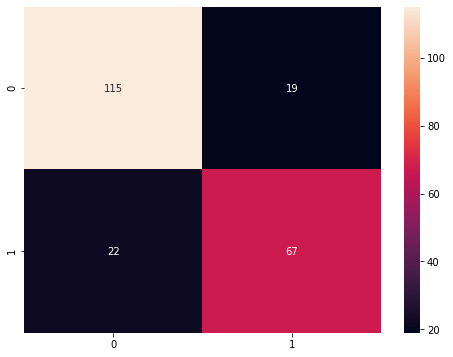

In [ ]:
visualize_model(knc_base)

In [ ]:
evaluate_model(knc_base, 'knc_base', final = True,
    X = X_train, y = y_train, train = True)

{'accuracy': 0.8532934131736527,
 'precision': 0.8414096916299559,
 'recall': 0.7549407114624506,
 'f1': 0.7958333333333333,
 'roc_auc': 0.8340968617553217}

In [26]:
knc_base_params = knc_base.get_params()
model_params['knc_base'] = knc_base_params

### Finding the best parameters

#### Parameters

The parameters for KNeighborsClassifier are:
* `n_neighbors`: int, default 5. Number of neighbors to use by default for kneighbors queries.
* `weights`: {‘uniform’, ‘distance’}, default ‘uniform’. Method of weighting the KNeighborsClassifier.
* `algorithm`: {‘auto’, ‘ball_tree’, ‘kd_tree’, ‘brute’}, default ‘auto’. Algorithm used to compute the nearest neighbors.
* `leaf_size`: int, default 30. Leaf size passed to BallTree or KDTree. This can affect the speed of the construction and query, as well as the memory required to store the tree.
* `p`: int, default 2. Parameter for the Minkowski metric from sklearn.metrics.pairwise.pairwise_distances. When p = 1, this is equivalent to using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.


Have a look on this article<a href="https://towardsdatascience.com/tree-algorithms-explained-ball-tree-algorithm-vs-kd-tree-vs-brute-force-9746debcd940"> BallTree vs KDTree vs Brute Force</a>.

#### Getting optimal values for `n_neighbors`

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, log_loss
range_ = list(range(2,25))
acuurecies = np.zeros(len(range_))
recalls = np.zeros(len(range_))
roc = np.zeros(len(range_))
losses = np.zeros(len(range_))
for i in range_:
    knc_base = KNeighborsClassifier(n_neighbors=i)
    knc_base.fit(X_train, y_train)
    preds = knc_base.predict(X_test)
    acuurecies[i-2] = accuracy_score(y_test, preds)
    recalls[i-2] = recall_score(y_test, preds)
    roc[i-2] = roc_auc_score(y_test, preds)
    losses[i-2] = log_loss(y_test, preds)

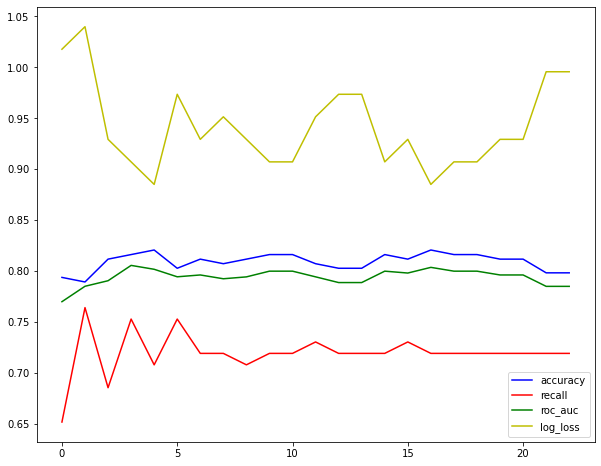

In [ ]:
plt.figure(figsize=(10,8))
x = np.arange(len(range_))
plt.plot(x, acuurecies, label='accuracy', color='blue')
plt.plot(x, recalls, "r-" ,label='recall')
plt.plot(x, roc, "g-", label='roc_auc')
plt.plot(x, losses/7, "y-", label='log_loss')
plt.legend()

The model performs better for k value of near 15. We'll be using the `GridSearchCV` to find the optimal value for `n_neighbors` nearest this k value.

In [ ]:
params = {"n_neighbors":[13,14,15,16,17,18,19,20], "weights":['uniform', 'distance'], 
    "algorithm":['auto', 'ball_tree', 'kd_tree', 'brute'],
    "leaf_size": [20, 30, 40, 50, 60, 70], "p": [1, 2]}

base_model = KNeighborsClassifier()
grid_3 = perform_grid_search(base_model, params, cv=3, play=False, verbose = 1, n_jobs = 4)

Fitting 3 folds for each of 768 candidates, totalling 2304 fits


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  56 tasks      | elapsed:    3.7s


Following is the best model and its parameters:
Best Model:
KNeighborsClassifier(n_neighbors=16, p=1)
Best params:
{'algorithm': 'auto', 'leaf_size': 30, 'n_neighbors': 16, 'p': 1, 'weights': 'uniform'}
Best score: 0.8469294202927756


[Parallel(n_jobs=4)]: Done 2260 tasks      | elapsed:    9.5s
[Parallel(n_jobs=4)]: Done 2304 out of 2304 | elapsed:    9.7s finished


In [ ]:
knn_final = grid_3.best_estimator_
evaluate_model(knn_final, 'knn_final', final = True)

{'accuracy': 0.8385650224215246,
 'precision': 0.8441558441558441,
 'recall': 0.7303370786516854,
 'f1': 0.7831325301204819,
 'roc_auc': 0.8203924199228576}

              precision    recall  f1-score   support

           0       0.84      0.91      0.87       134
           1       0.84      0.73      0.78        89

    accuracy                           0.84       223
   macro avg       0.84      0.82      0.83       223
weighted avg       0.84      0.84      0.84       223



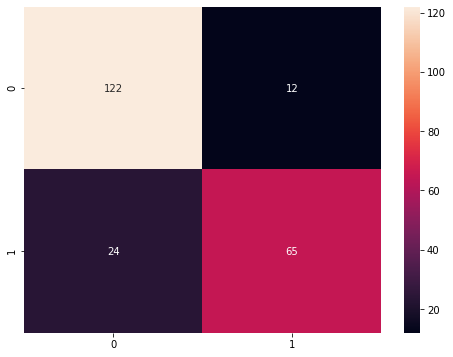

In [ ]:
visualize_model(knn_final)

In [ ]:
evaluate_model(knn_final, 'knn_final', final = True,
    X = X_train, y = y_train, train = True)

{'accuracy': 0.8323353293413174,
 'precision': 0.8652849740932642,
 'recall': 0.6600790513833992,
 'f1': 0.7488789237668161,
 'roc_auc': 0.7987142244868802}

In [ ]:
pd.DataFrame(models_on_train).T

,accuracy,precision,recall,f1,roc_auc
lr_base,0.853293,0.829787,0.770751,0.799180,0.837183
lr_final,0.851796,0.831897,0.762846,0.795876,0.834435
knc_base,0.853293,0.841410,0.754941,0.795833,0.834097
knn_final,0.832335,0.865285,0.660079,0.748879,0.798714


In [40]:
model_params["knn_final"] ={'algorithm': 'auto', 'leaf_size': 30, 
    'n_neighbors': 16, 'p': 1, 'weights': 'uniform'}

Well, it is performing better than the Logistic Regression model.

## SVC

### Default Parameters

In [28]:
from sklearn.svm import SVC
svc_base = SVC(random_state=101)
svc_base.fit(X_train, y_train)
evaluate_model(svc_base, 'svc_base', final = True)

{'accuracy': 0.8340807174887892,
 'precision': 0.8170731707317073,
 'recall': 0.7528089887640449,
 'f1': 0.783625730994152,
 'roc_auc': 0.8204343451282912}

In [29]:
model_params["svc_base"] = svc_base.get_params()

              precision    recall  f1-score   support

           0       0.84      0.89      0.87       134
           1       0.82      0.75      0.78        89

    accuracy                           0.83       223
   macro avg       0.83      0.82      0.82       223
weighted avg       0.83      0.83      0.83       223



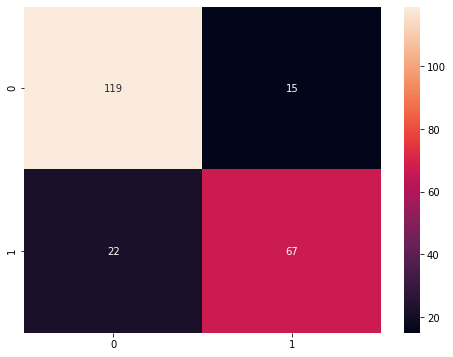

In [ ]:
visualize_model(svc_base)

In [ ]:
evaluate_model(svc_base, 'svc_base', final = True,
    X = X_train, y = y_train, train = True)

{'accuracy': 0.8368263473053892,
 'precision': 0.8130434782608695,
 'recall': 0.7391304347826086,
 'f1': 0.7743271221532091,
 'roc_auc': 0.8177579884756416}

Even this model with default parameters performs better than the Logistic Regression model. Let's see if we can beat the default parameters.

### Finding the best parameters

#### Parameters

`sklearn.svm.SVC` has the following parameters:
* `C`: float, default 1.0. Inverse of regularization strength; must be a positive float. Like in SVM, smaller values specify stronger regularization.
* `kernel`: {‘linear’, ‘poly’, ‘rbf’, ‘sigmoid’, ‘precomputed’}, default ‘rbf’. Specifies the kernel type to be used in the algorithm.
* `degree`: int, default 3. Degree of the polynomial kernel function (‘poly’). Ignored by all other kernels.
* `gamma`: float, default ‘auto’. Kernel coefficient for ‘rbf’, ‘poly’ and ‘sigmoid’. If gamma is ‘auto’ then 1/n_features will be used instead.
* `coef0`: float, default 0.0. Independent term in kernel function. It is only significant in ‘poly’ and ‘sigmoid’.

To narrow down the grid search, we know that 'rbf' kernel usually works best, so let's try that.

In [ ]:
svc_base.get_params()

{'C': 1.0,
 'break_ties': False,
 'cache_size': 200,
 'class_weight': None,
 'coef0': 0.0,
 'decision_function_shape': 'ovr',
 'degree': 3,
 'gamma': 'scale',
 'kernel': 'rbf',
 'max_iter': -1,
 'probability': False,
 'random_state': 101,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

In [19]:
params = {'C': [0.1, 0.5, 1.0, 2.0], 'kernel': ['rbf','sigmoid'],
        'gamma': [0.1, 0.5, 1.0, 2.0, 'scale', 'auto'],
        'coef0': [0.0, 0.1, 0.2, 0.3]}
svc_base = SVC(random_state=101) 
grid_4 = perform_grid_search(svc_base, params, text=False, cv=3, 
        play = False, verbose = 1, n_jobs = 4)
evaluate_model(grid_4.best_estimator_)

Fitting 3 folds for each of 192 candidates, totalling 576 fits


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  68 tasks      | elapsed:    3.1s


Following is the best model and its parameters:
Best Model:
SVC(C=0.1, gamma=0.1, random_state=101)
Best params:
{'C': 0.1, 'coef0': 0.0, 'gamma': 0.1, 'kernel': 'rbf'}
Best score: 0.8544958747409575


[Parallel(n_jobs=4)]: Done 576 out of 576 | elapsed:    5.3s finished


{'accuracy': 0.8251121076233184,
 'precision': 0.7906976744186046,
 'recall': 0.7640449438202247,
 'f1': 0.7771428571428571,
 'roc_auc': 0.8148582928056348}

Let's try 'poly' kernel too.

In [20]:
params = {'C': [0.1, 0.3, 0.2, 0.4, 0.5], 'kernel': ['poly'],
        'degree': [2, 3, 4, 5, 6], 
        }
svc_base = SVC(random_state=101) 
grid_5 = perform_grid_search(svc_base, params, text=False, cv=5, verbose=0, play = False)
evaluate_model(grid_5.best_estimator_)

Following is the best model and its parameters:
Best Model:
SVC(C=0.2, degree=2, kernel='poly', random_state=101)
Best params:
{'C': 0.2, 'degree': 2, 'kernel': 'poly'}
Best score: 0.8628112449799197


{'accuracy': 0.7892376681614349,
 'precision': 0.7282608695652174,
 'recall': 0.7528089887640449,
 'f1': 0.7403314917127071,
 'roc_auc': 0.7831209122924702}

As promised, the model 'rbf' kernel performs better. However, our search for best hyperparameters did not yield any useful results. The model with default parameters performs better. Still!

In [21]:
svc_final = grid_4.best_estimator_
evaluate_model(svc_final, 'svc_final', final = True)

{'accuracy': 0.8251121076233184,
 'precision': 0.7906976744186046,
 'recall': 0.7640449438202247,
 'f1': 0.7771428571428571,
 'roc_auc': 0.8148582928056348}

In [22]:
evaluate_model(svc_final, 'svc_final', final = True,
    X = X_train, y = y_train, train = True)

{'accuracy': 0.8368263473053892,
 'precision': 0.8103448275862069,
 'recall': 0.7430830039525692,
 'f1': 0.7752577319587629,
 'roc_auc': 0.8185294537835136}

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       134
           1       0.79      0.74      0.76        89

    accuracy                           0.82       223
   macro avg       0.81      0.80      0.81       223
weighted avg       0.82      0.82      0.82       223



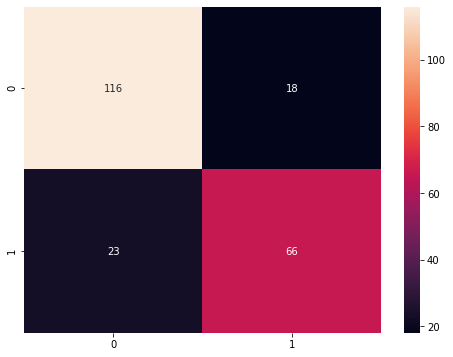

In [ ]:
visualize_model(svc_final)

The model with default parameters performs better than the fine tuned one.

In [ ]:
pd.DataFrame(models_performance).T

,accuracy,precision,recall,f1,roc_auc
lr_base,0.802691,0.747253,0.764045,0.755556,0.796202
lr_gs_final,0.820628,0.769231,0.786517,0.777778,0.814900
knc_base,0.816143,0.779070,0.752809,0.765714,0.805509
knn_final,0.838565,0.844156,0.730337,0.783133,0.820392
svc_base,0.834081,0.817073,0.752809,0.783626,0.820434
svc_final,0.816143,0.785714,0.741573,0.763006,0.803622
dt_base,0.780269,0.708333,0.764045,0.735135,0.777545
dt_final,0.829596,0.800000,0.764045,0.781609,0.818590
rf_base,0.816143,0.766667,0.775281,0.770950,0.809282
rf_final,0.820628,0.802469,0.730337,0.764706,0.805467


In [41]:
model_params["svc_final"] = {'C': 0.1, 'coef0': 0.0, 'gamma': 0.1, 'kernel': 'rbf'}

## Decision Tree

### Default Parameters

In [35]:
from sklearn.tree import DecisionTreeClassifier
dt_base = DecisionTreeClassifier()
dt_base.fit(X_train, y_train)

DecisionTreeClassifier()

In [36]:
model_params["dt_base"] = dt_base.get_params()

In [24]:
evaluate_model(dt_base, 'dt_base', final = True)

{'accuracy': 0.7847533632286996,
 'precision': 0.7157894736842105,
 'recall': 0.7640449438202247,
 'f1': 0.7391304347826086,
 'roc_auc': 0.781276203253396}

In [25]:
evaluate_model(dt_base, 'dt_base', final = True,
    X = X_train, y = y_train, train = True)

{'accuracy': 0.9895209580838323,
 'precision': 0.9959677419354839,
 'recall': 0.9762845849802372,
 'f1': 0.9860279441117764,
 'roc_auc': 0.9869374732130103}

The model is definetly overfitting. The main reason for that is the fact that the `max_depth` parameter has a defualt value of `None`. Let's fix that to some definate value.

In [31]:
dt_base = DecisionTreeClassifier(max_depth=10, random_state=101)
dt_base.fit(X_train, y_train)
evaluate_model(dt_base, 'dt_base', final = True)

{'accuracy': 0.8116591928251121,
 'precision': 0.7701149425287356,
 'recall': 0.7528089887640449,
 'f1': 0.7613636363636362,
 'roc_auc': 0.8017776287103806}

In [32]:
evaluate_model(dt_base, 'dt_base', final = True,
    X = X_train, y = y_train, train = True)

{'accuracy': 0.9401197604790419,
 'precision': 0.9733333333333334,
 'recall': 0.8656126482213439,
 'f1': 0.9163179916317992,
 'roc_auc': 0.9255774084480213}

Much better. Let's see if we can beat the default parameters.

### Finding the best parameters

Parameters for Decision Tree are:
* `criterion`: {‘gini’, ‘entropy’}, default ‘gini’. The function to measure the quality of a split.
*`splitter’: {‘best’, ‘random’}, default ‘best’. The strategy used to choose the split at each node.
* `max_depth`: int, default None. The maximum depth of the tree. If None, then nodes are expanded until all leaves are pure or until all leaves contain less than min_samples_split samples.
* `min_sample_leaf`: int or float, default 1. The minimum number of samples required to be at a leaf node.
    - If int, then consider min_samples_leaf as the minimum number.
    - If float, then min_samples_leaf is a fraction and ceil(min_samples_leaf * n_samples) are the minimum number of samples for each node.
* `min_samples_split`: int, default 2. The minimum number of samples required to split an internal node.
* `max_features`: int, float, string or None, default ‘auto’. The number of features to consider when looking for the best split:
    - If int, then consider `max_features` features at each split.
    - If float, then `max_features` is a percentage and a random number of features are considered at each split.
    - If “auto”, then `max_features=sqrt(n_features)`.
    - If “sqrt”, then `max_features=sqrt(n_features)`.
    - If “log2”, then `max_features=log2(n_features)`.
    - If None, then `max_features=n_features`.

In [ ]:
params = {'criterion': ['gini', 'entropy'], 
    'max_depth': [2, 4, 6, 8, 10, 12],
    'min_samples_split': [2, 4, 6, 8, 10, 12],
    'min_samples_leaf': [1, 2, 4, 6, 8, 10],
    'max_features': ['auto', 'sqrt', 'log2', None],
}

dt_base = DecisionTreeClassifier(random_state=101)
grid_6 = perform_grid_search(dt_base, params, cv=3, text=False, play=False, verbose=1)

Fitting 3 folds for each of 1728 candidates, totalling 5184 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


Following is the best model and its parameters:
    Best Model:
DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, random_state=101)
Best params:
    
{'criterion': 'gini', 'max_depth': 4, 'max_features': None, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best score: 0.8544801657151929


[Parallel(n_jobs=1)]: Done 5184 out of 5184 | elapsed:   20.1s finished


Let's try to narrow down the grid search based on above parameters.

In [ ]:
grid_6.best_params_

{'criterion': 'gini',
 'max_depth': 4,
 'max_features': None,
 'min_samples_leaf': 10,
 'min_samples_split': 2}

In [ ]:
params = {'criterion': ['gini'],
 'max_depth': [3,4,5],
 'max_features': [None],
 'min_samples_leaf': [9,10,11,12],
 'min_samples_split': [2,3]}
grid_7 = perform_grid_search(dt_base, params, cv=3, text=False, play=False, verbose=0)

Following is the best model and its parameters:
    Best Model:
DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, random_state=101)
Best params:
    
{'criterion': 'gini', 'max_depth': 4, 'max_features': None, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best score: 0.8544801657151929


This should be the final one.

In [34]:
parameters = {'criterion': 'gini', 'max_depth': 4, 'max_features': None, 
    'min_samples_leaf': 10, 'min_samples_split': 2}
dt_final = DecisionTreeClassifier(random_state=101, **parameters)
dt_final.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, random_state=101)

In [ ]:
dt_final =  grid_7.best_estimator_
evaluate_model(dt_final, 'dt_final', final = True)

{'accuracy': 0.8295964125560538,
 'precision': 0.8,
 'recall': 0.7640449438202247,
 'f1': 0.7816091954022989,
 'roc_auc': 0.8185896360892169}

In [36]:
evaluate_model(dt_final, 'dt_final', final = True,
    X = X_train, y = y_train, train = True)

{'accuracy': 0.8368263473053892,
 'precision': 0.7975206611570248,
 'recall': 0.7628458498023716,
 'f1': 0.7797979797979798,
 'roc_auc': 0.8223867803228725}

In [42]:
model_params["dt_final"] = {'criterion': 'gini', 'max_depth': 4, 'max_features': None, 
    'min_samples_leaf': 10, 'min_samples_split': 2}

## Random Forest

### Default Parameters

There will be an overfitting with default parameters, just like the `DecisionTreeClassifier`. To fix this, we'll set `max_depth` to a definite value.

In [38]:
from sklearn.ensemble import RandomForestClassifier
rf_base = RandomForestClassifier(max_depth = 10, random_state=101)
rf_base.fit(X_train, y_train)
evaluate_model(rf_base, 'rf_base', final = True)

{'accuracy': 0.8161434977578476,
 'precision': 0.7926829268292683,
 'recall': 0.7303370786516854,
 'f1': 0.760233918128655,
 'roc_auc': 0.8017357035049472}

In [39]:
model_params["rf_base"] = rf_base.get_params()

In [48]:
evaluate_model(rf_base, 'rf_base', final = True,
    X = X_train, y = y_train, train = True)

{'accuracy': 0.9356287425149701,
 'precision': 0.981651376146789,
 'recall': 0.8458498023715415,
 'f1': 0.9087048832271761,
 'roc_auc': 0.9181056240773371}

### Finding the best parameters

The parameters for Random Forest are:
* `n_estimators`: int, default 10. The number of trees in the forest.
* `bootstrap`: bool, default True. Whether bootstrap samples are used when building trees.

Almost all the other parameters are the same as for Decision Tree.

We'll be using the final params used to search for the best parameters in Decision Tree for Random Forest.

In [ ]:
params = {'n_estimators': [40, 50, 60,70,80], 
    "bootstrap": [True, False],
    'criterion': ['gini', 'entropy'], 
    'max_depth': [2, 4, 6, 8, 10, 12],
    'min_samples_split': [2, 4, 6, 8, 10, 12],
    'min_samples_leaf': [1, 2, 4, 6, 8, 10],
    'max_features': ['auto', 'sqrt', 'log2', None],
}
rf_base = RandomForestClassifier(random_state=101)
grid_8 = perform_grid_search(rf_base, params, text = True, play = False, verbose=1, cv = 3)

Fitting 3 folds for each of 17280 candidates, totalling 51840 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done 51840 out of 51840 | elapsed: 98.1min finished


SM540f9977c6f74742831173cd24ac281e
Following is the best model and its parameters:
    Best Model:
RandomForestClassifier(criterion='entropy', max_depth=6, max_features=None,
                       min_samples_split=10, n_estimators=40, random_state=101)
Best params:
    
{'bootstrap': True, 'criterion': 'entropy', 'max_depth': 6, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 40}
Best score: 0.8742938215497508


In [ ]:
params = { 'n_estimators': [30,35,40,45,50], 
    "bootstrap": [True],
    'criterion': ['entropy'],
    'max_depth': [5,6,7],
    'max_features': [None],
    'min_samples_leaf': [1,2], 
    'min_samples_split': [9,10,11],
}

rf_base = RandomForestClassifier(random_state=101)
grid_9 = perform_grid_search(rf_base, params, text = False, play = True, verbose=1, cv = 3)

Fitting 3 folds for each of 90 candidates, totalling 270 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done 270 out of 270 | elapsed:   25.1s finished


Following is the best model and its parameters:
    Best Model:
RandomForestClassifier(criterion='entropy', max_depth=6, max_features=None,
                       min_samples_split=11, n_estimators=30, random_state=101)
Best params:
    
{'bootstrap': True, 'criterion': 'entropy', 'max_depth': 6, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 11, 'n_estimators': 30}
Best score: 0.8755361743974689


Let's narrow it down

In [ ]:
params = { 'n_estimators': [30], 
    "bootstrap": [True],
    'criterion': ['entropy'],
    'max_depth': [6],
    'max_features': [None],
    'min_samples_leaf': [1], 
    'min_samples_split': [14,15,18,20],
}

rf_base = RandomForestClassifier(random_state=101)
grid_9 = perform_grid_search(rf_base, params, text = False, play = False, verbose=1, cv = 3)

Fitting 3 folds for each of 4 candidates, totalling 12 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


Following is the best model and its parameters:
    Best Model:
RandomForestClassifier(criterion='entropy', max_depth=6, max_features=None,
                       min_samples_split=14, n_estimators=30, random_state=101)
Best params:
    
{'bootstrap': True, 'criterion': 'entropy', 'max_depth': 6, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 14, 'n_estimators': 30}
Best score: 0.8762128051790695


[Parallel(n_jobs=1)]: Done  12 out of  12 | elapsed:    0.9s finished


This should be the final one.

In [50]:
parameters = {'bootstrap': True, 'criterion': 'entropy', 
    'max_depth': 6, 'max_features': None, 'min_samples_leaf': 1, 
    'min_samples_split': 14, 'n_estimators': 30}

rf_final = RandomForestClassifier(random_state=101, **parameters)
rf_final.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', max_depth=6, max_features=None,
                       min_samples_split=14, n_estimators=30, random_state=101)

In [ ]:
rf_final = grid_9.best_estimator_
evaluate_model(rf_final, 'rf_final', final = True)

{'accuracy': 0.820627802690583,
 'precision': 0.8024691358024691,
 'recall': 0.7303370786516854,
 'f1': 0.7647058823529411,
 'roc_auc': 0.8054670467885293}

In [51]:
evaluate_model(rf_final, 'rf_final', final = True,
    X = X_train, y = y_train, train = True)

{'accuracy': 0.8892215568862275,
 'precision': 0.92018779342723,
 'recall': 0.7747035573122529,
 'f1': 0.8412017167381973,
 'roc_auc': 0.8668698509452831}

In [43]:
model_params["rf_final"] = {'bootstrap': True, 'criterion': 'entropy', 
    'max_depth': 6, 'max_features': None, 'min_samples_leaf': 1, 
    'min_samples_split': 14, 'n_estimators': 30}

## Gausian Naive Bayes

### GuassianNB

In [52]:
from sklearn.naive_bayes import GaussianNB

gnb_base = GaussianNB()
gnb_base.fit(X_train, y_train)

GaussianNB()

In [53]:
evaluate_model(gnb_base, 'gnb_base', final = True)

{'accuracy': 0.4349775784753363,
 'precision': 0.41232227488151657,
 'recall': 0.9775280898876404,
 'f1': 0.5800000000000001,
 'roc_auc': 0.5260774777796411}

It is doing really terrible! No need to search for the best parameters then!

In [54]:
evaluate_model(gnb_base, 'gnb_base', final = True,
    X = X_train, y = y_train, train = True)

{'accuracy': 0.4251497005988024,
 'precision': 0.39652448657187994,
 'recall': 0.9920948616600791,
 'f1': 0.5665914221218962,
 'roc_auc': 0.5358064669746179}

In [44]:
model_params.close()